In [40]:
import numpy as np
import os
from pathlib import Path
import pandas as pd
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Ellipse
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

### Fisher matrix

$$F_{\alpha\beta} = \frac{\partial \mathbf{O}^{T}}{\partial \theta_{\alpha}} \, \mathbf{C}^{-1} \, \frac{\partial \mathbf{O}}{\partial \theta_{\beta}}$$


$\mathbf{O}$ would be my vector of observables

$\theta$ the cosmological param
$$\theta = \{\omega_b,\omega_{\mathrm{cdm}},n_s,\sigma_8\}$$

$\mathbf{C}$ the cov matrix

--------> I have ASTRA classification/probabilities

1. Use astra probability as a marker:

$$\mathbf{O} = \left[ \frac{P_{\mathrm{void}}(k)}
{P(k)},
\,
\frac{P_{\mathrm{sheet}}(k)}
     {P(k)},
\,
\frac{P_{\mathrm{fil}}(k)}
     {P(k)},
\,
\frac{P_{\mathrm{knot}}(k)}
     {P(k)}
\right]$$

Using ``hod091``

In [2]:
base_path = Path('/pscratch/sd/v/vtorresg/marked_pk')

In [3]:
cosmo_ids = ['100', '101', '102', '103', '104', '105', '112', '113']
c_hod = '091'

In [4]:
cosmo = {cid: pd.read_csv(base_path / f'c{cid}' / f'hod{c_hod}' / f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{c_hod}_N256.csv')
         for cid in cosmo_ids}

In [5]:
cosmo['100'].columns

Index(['k_h_mpc', 'pk_raw', 'pk_used', 'nmodes', 'pk_window', 'pk_over_window',
       'pk_marked_raw_pvoid', 'pk_marked_used_pvoid',
       'pk_marked_over_unmarked_pvoid', 'pk_marked_over_unmarked_masked_pvoid',
       'delta_pk_marked_minus_unmarked_pvoid', 'pk_marked_raw_psheet',
       'pk_marked_used_psheet', 'pk_marked_over_unmarked_psheet',
       'pk_marked_over_unmarked_masked_psheet',
       'delta_pk_marked_minus_unmarked_psheet', 'pk_marked_raw_pfilament',
       'pk_marked_used_pfilament', 'pk_marked_over_unmarked_pfilament',
       'pk_marked_over_unmarked_masked_pfilament',
       'delta_pk_marked_minus_unmarked_pfilament', 'pk_marked_raw_pknot',
       'pk_marked_used_pknot', 'pk_marked_over_unmarked_pknot',
       'pk_marked_over_unmarked_masked_pknot',
       'delta_pk_marked_minus_unmarked_pknot'],
      dtype='object')

In [6]:
classes = ['pvoid', 'psheet', 'pfilament', 'pknot']

obs_cols = [f'pk_marked_over_unmarked_{c}' for c in classes]

get something like ``k0_pvoid, k0_psheet, k0_pfilament, k0_pknot``

In [7]:
O = {cid: cosmo[cid][obs_cols].to_numpy().ravel() for cid in cosmo_ids}

O_mat = np.vstack([O[cid] for cid in cosmo_ids])
O_mat

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(8, 512))

Take out the ones with nan values

and might be better to get something like ``pvoid(k0...kN), psheet(k0...kN), pfilament(k0...kN), pknot(k0...kN)``

In [8]:
kmin = 0.02
kmax = 0.20

In [9]:
mask_k = np.ones(len(cosmo['100']), dtype=bool)

for cid in cosmo_ids:
    mask_k &= np.isfinite(cosmo[cid][obs_cols]).all(axis=1)
mask_k &= cosmo['100']['k_h_mpc'].between(kmin, kmax).to_numpy()

In [10]:
O = {cid: cosmo[cid].loc[mask_k, obs_cols].to_numpy().T.ravel()
    for cid in cosmo_ids}

O_mat = np.vstack([O[cid] for cid in cosmo_ids])
O_mat.shape

(8, 56)

In [11]:
O_mat.shape

(8, 56)

| Cosmo |  |
|------------|-------------|
| c000 | fiducial |
| c100 | $+\omega_b$ |
| c101 | $-\omega_b$ |
| c102 | $+\omega_{\mathrm{cdm}}$ |
| c103 | $-\omega_{\mathrm{cdm}}$ |
| c104 | $+n_s$ |
| c105 | $-n_s$ |
| c112 | $+\sigma_8$ |
| c113 | $-\sigma_8$ |

for c100,c101 and c102,c103 the changes are log:  $\pm 2\% \ln{(\omega_b)}$

In [12]:
#fiducial c000
omega_b = 0.02237
omega_cdm = 0.12000
n_s = 0.96490
sigma8_m = 0.807952
sigma8_cb = 0.811355

| param          | cosmo + | cosmo - |  val + |  val - |                   delta    |
| ------------------ | ------------ | ------------ | -------: | -------: | -------------------------------: |
| $\omega_b$         | c100         | c101         |  0.02282 |  0.02193 |    0.00089 |
| $\omega_{\rm cdm}$ | c102         | c103         |  0.12400 |  0.11610 |    0.00790 |
| $n_s$              | c104         | c105         |  0.97490 |  0.95490 |    0.02000 |
| $\sigma_8$         | c112         | c113         | 0.824120 | 0.792107 | 0.032013 |


In [13]:
delta_wb = 0.02282 - 0.02193
delta_ln_wb = 0.04

delta_wcdm = 0.12400 - 0.11610
delta_ln_wcdm = 0.066

delta_ns = 0.97490 - 0.95490
delta_sigma8 = 0.824120 - 0.792107

$2 \Delta \theta = \theta_+ - \theta_-$

$$\frac{\partial \mathcal{O}}{\partial \omega_b}
\approx
\frac{\mathcal{O}_{c100}-\mathcal{O}_{c101}}{0.00089}$$

In [14]:
dO_dwb = (O['100'] - O['101']) / delta_wb
# dO_dlnwb = (O['100'] - O['101']) / delta_ln_wb

$$\frac{\partial \mathcal{O}}{\partial \omega_{\mathrm{cdm}}}
\approx
\frac{\mathcal{O}_{c102}-\mathcal{O}_{c103}}{0.00790}$$

In [15]:
dO_dwcdm = (O['102'] - O['103']) / delta_wcdm
# dO_dlnwcdm = (O['102'] - O['103']) / delta_ln_wcdm

$$\frac{\partial \mathcal{O}}{\partial n_s}
\approx
\frac{\mathcal{O}_{c104}-\mathcal{O}_{c105}}{0.02000}$$

In [16]:
dO_dns = (O['104'] - O['105']) / delta_ns

$$\frac{\partial \mathcal{O}}{\partial \sigma_8}
\approx
\frac{\mathcal{O}_{c112}-\mathcal{O}_{c113}}{0.032013}$$

In [17]:
dO_dsigma8 = (O['112'] - O['113']) / delta_sigma8

In [18]:
D = np.vstack([dO_dwb, dO_dwcdm, dO_dns, dO_dsigma8])
D.shape

(4, 56)

In [131]:
param_names = [r'$\omega_b$',
               r'$\omega_{\rm cdm}$',
               r'$n_s$',
               r'$\sigma_8$']

#### Check

In [20]:
Nk = mask_k.sum()
k = cosmo['100'].loc[mask_k, 'k_h_mpc'].to_numpy()

In [21]:
derivatives = {param_names[0]: dO_dwb,
               param_names[1]: dO_dwcdm,
               param_names[2]: dO_dns,
               param_names[3]: dO_dsigma8}

In [22]:
# for j, (par, dO) in enumerate(derivatives.items()):
#     plt.figure(figsize=(7, 5))

#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         plt.plot(k, y, label=c)

#     plt.axhline(0, ls='--', color='white', alpha=0.5)
#     plt.grid(lw=0.3, alpha=0.25)
    
#     plt.xscale('log')
#     plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     plt.ylabel(rf'$\partial O / \partial ${par}')
#     plt.title(f'HOD{c_hod}')
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f'./plots/deriv/deriv_hod{c_hod}_param_{j}.png', dpi=360)
#     plt.show()

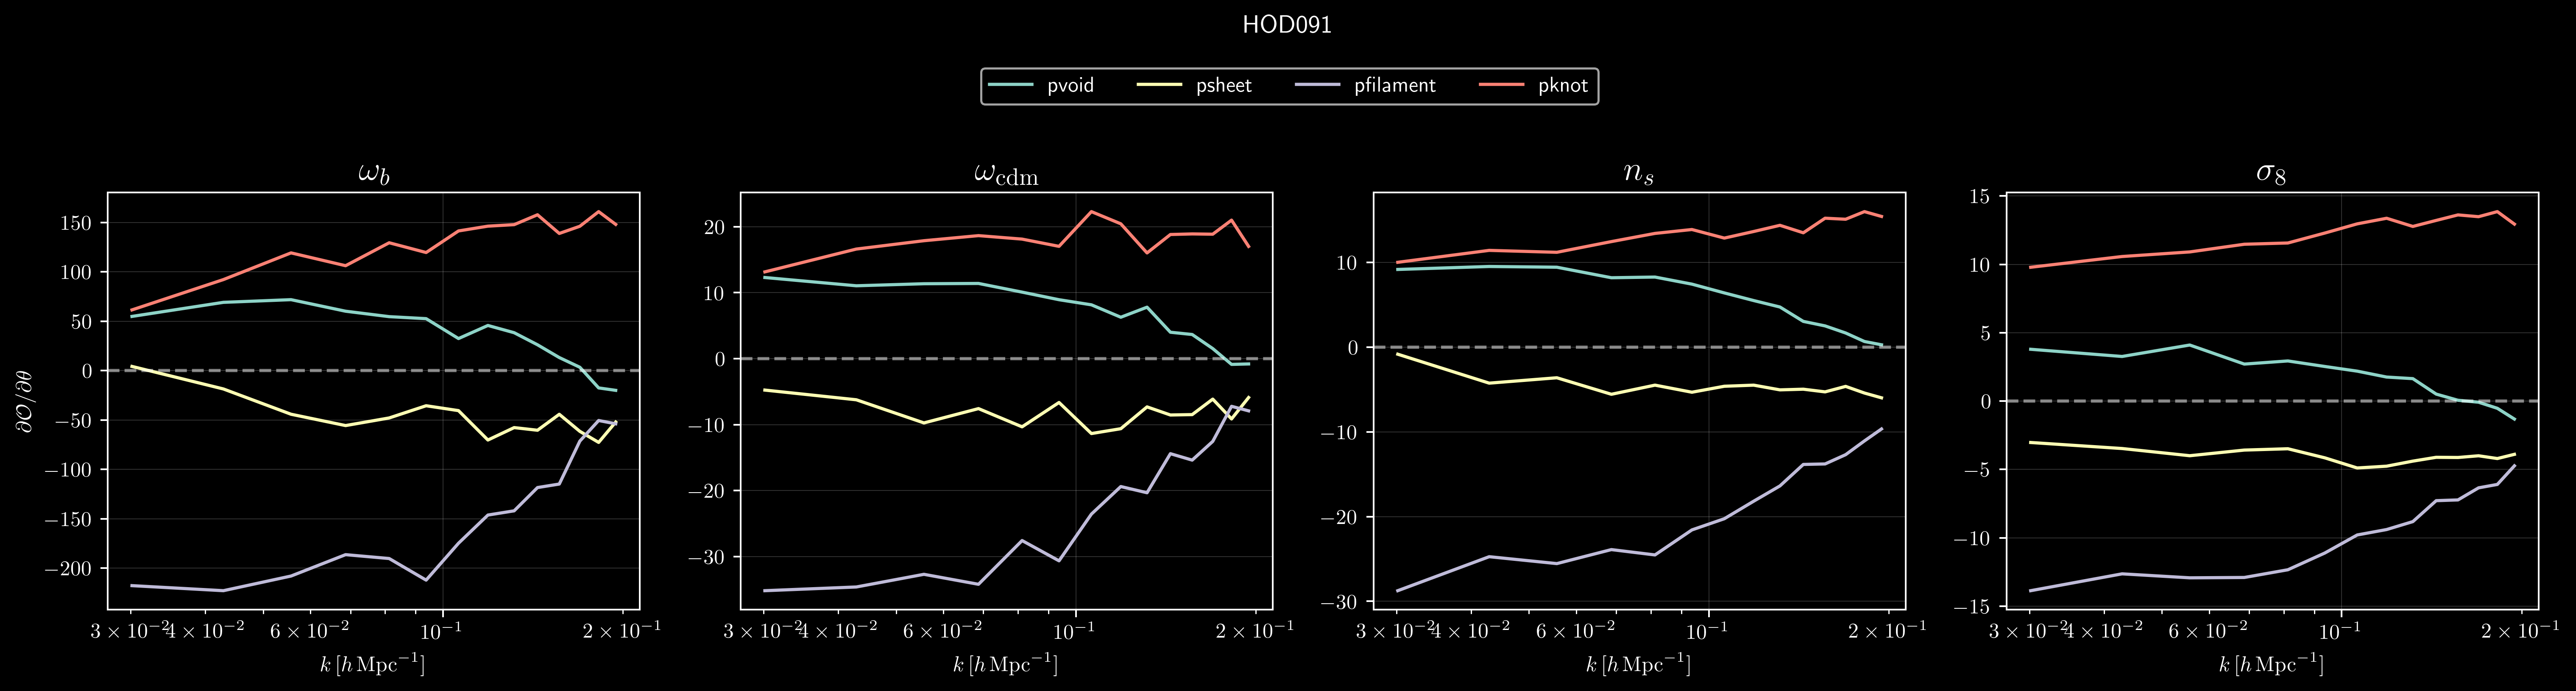

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True)

for j, ((par, dO), ax) in enumerate(zip(derivatives.items(), axes)):

    for i, c in enumerate(classes):
        y = dO[i*Nk:(i+1)*Nk]
        ax.plot(k, y, label=c)

    ax.axhline(0, ls='--', color='white', alpha=0.5)
    ax.grid(lw=0.3, alpha=0.25)
    ax.set_xscale('log')

    ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
    ax.set_title(param_names[j], fontsize=16)

axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(classes), bbox_to_anchor=(0.5, 1.05))

fig.suptitle(f'HOD{c_hod}', y=1.12)

plt.tight_layout()
# plt.savefig(f'./plots/deriv/deriv_hod{c_hod}_all_params.png',dpi=360,
           # bbox_inches='tight')
plt.show()

In [24]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hods.append(p.name.replace('hod', ''))
            
    return sorted(hods)

In [25]:
hods_fid = get_available_hods('000')
len(hods_fid)

500

In [26]:
kmin = 0.02
kmax = 0.20

In [27]:
def build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax):
    O_fid_all = []
    k_ref = None
    
    for hod in hods_fid:
        df = load_pk_dataframe('000', hod)
        
        mask = np.isfinite(df[obs_cols]).all(axis=1)
        mask &= df['k_h_mpc'].between(kmin, kmax)
        
        k_this = df.loc[mask, 'k_h_mpc'].to_numpy()
        
        k_ref = k_this
        O = df.loc[mask, obs_cols].to_numpy().T.ravel()
        O_fid_all.append(O)
    
    O_fid_all = np.array(O_fid_all)
    
    return O_fid_all, k_ref

In [28]:
def load_pk_dataframe(cid, hod):
    filename = (base_path / f'c{cid}' / f'hod{hod}' /
                f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{hod}_N256.csv')
    return pd.read_csv(filename)

In [29]:
O_fid_all, k_cov = build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax)
O_fid_all.shape

(500, 56)

In [31]:
C = np.cov(O_fid_all, rowvar=False, ddof=1)

In [32]:
std = np.sqrt(np.diag(C))
Corr = C / np.outer(std, std)

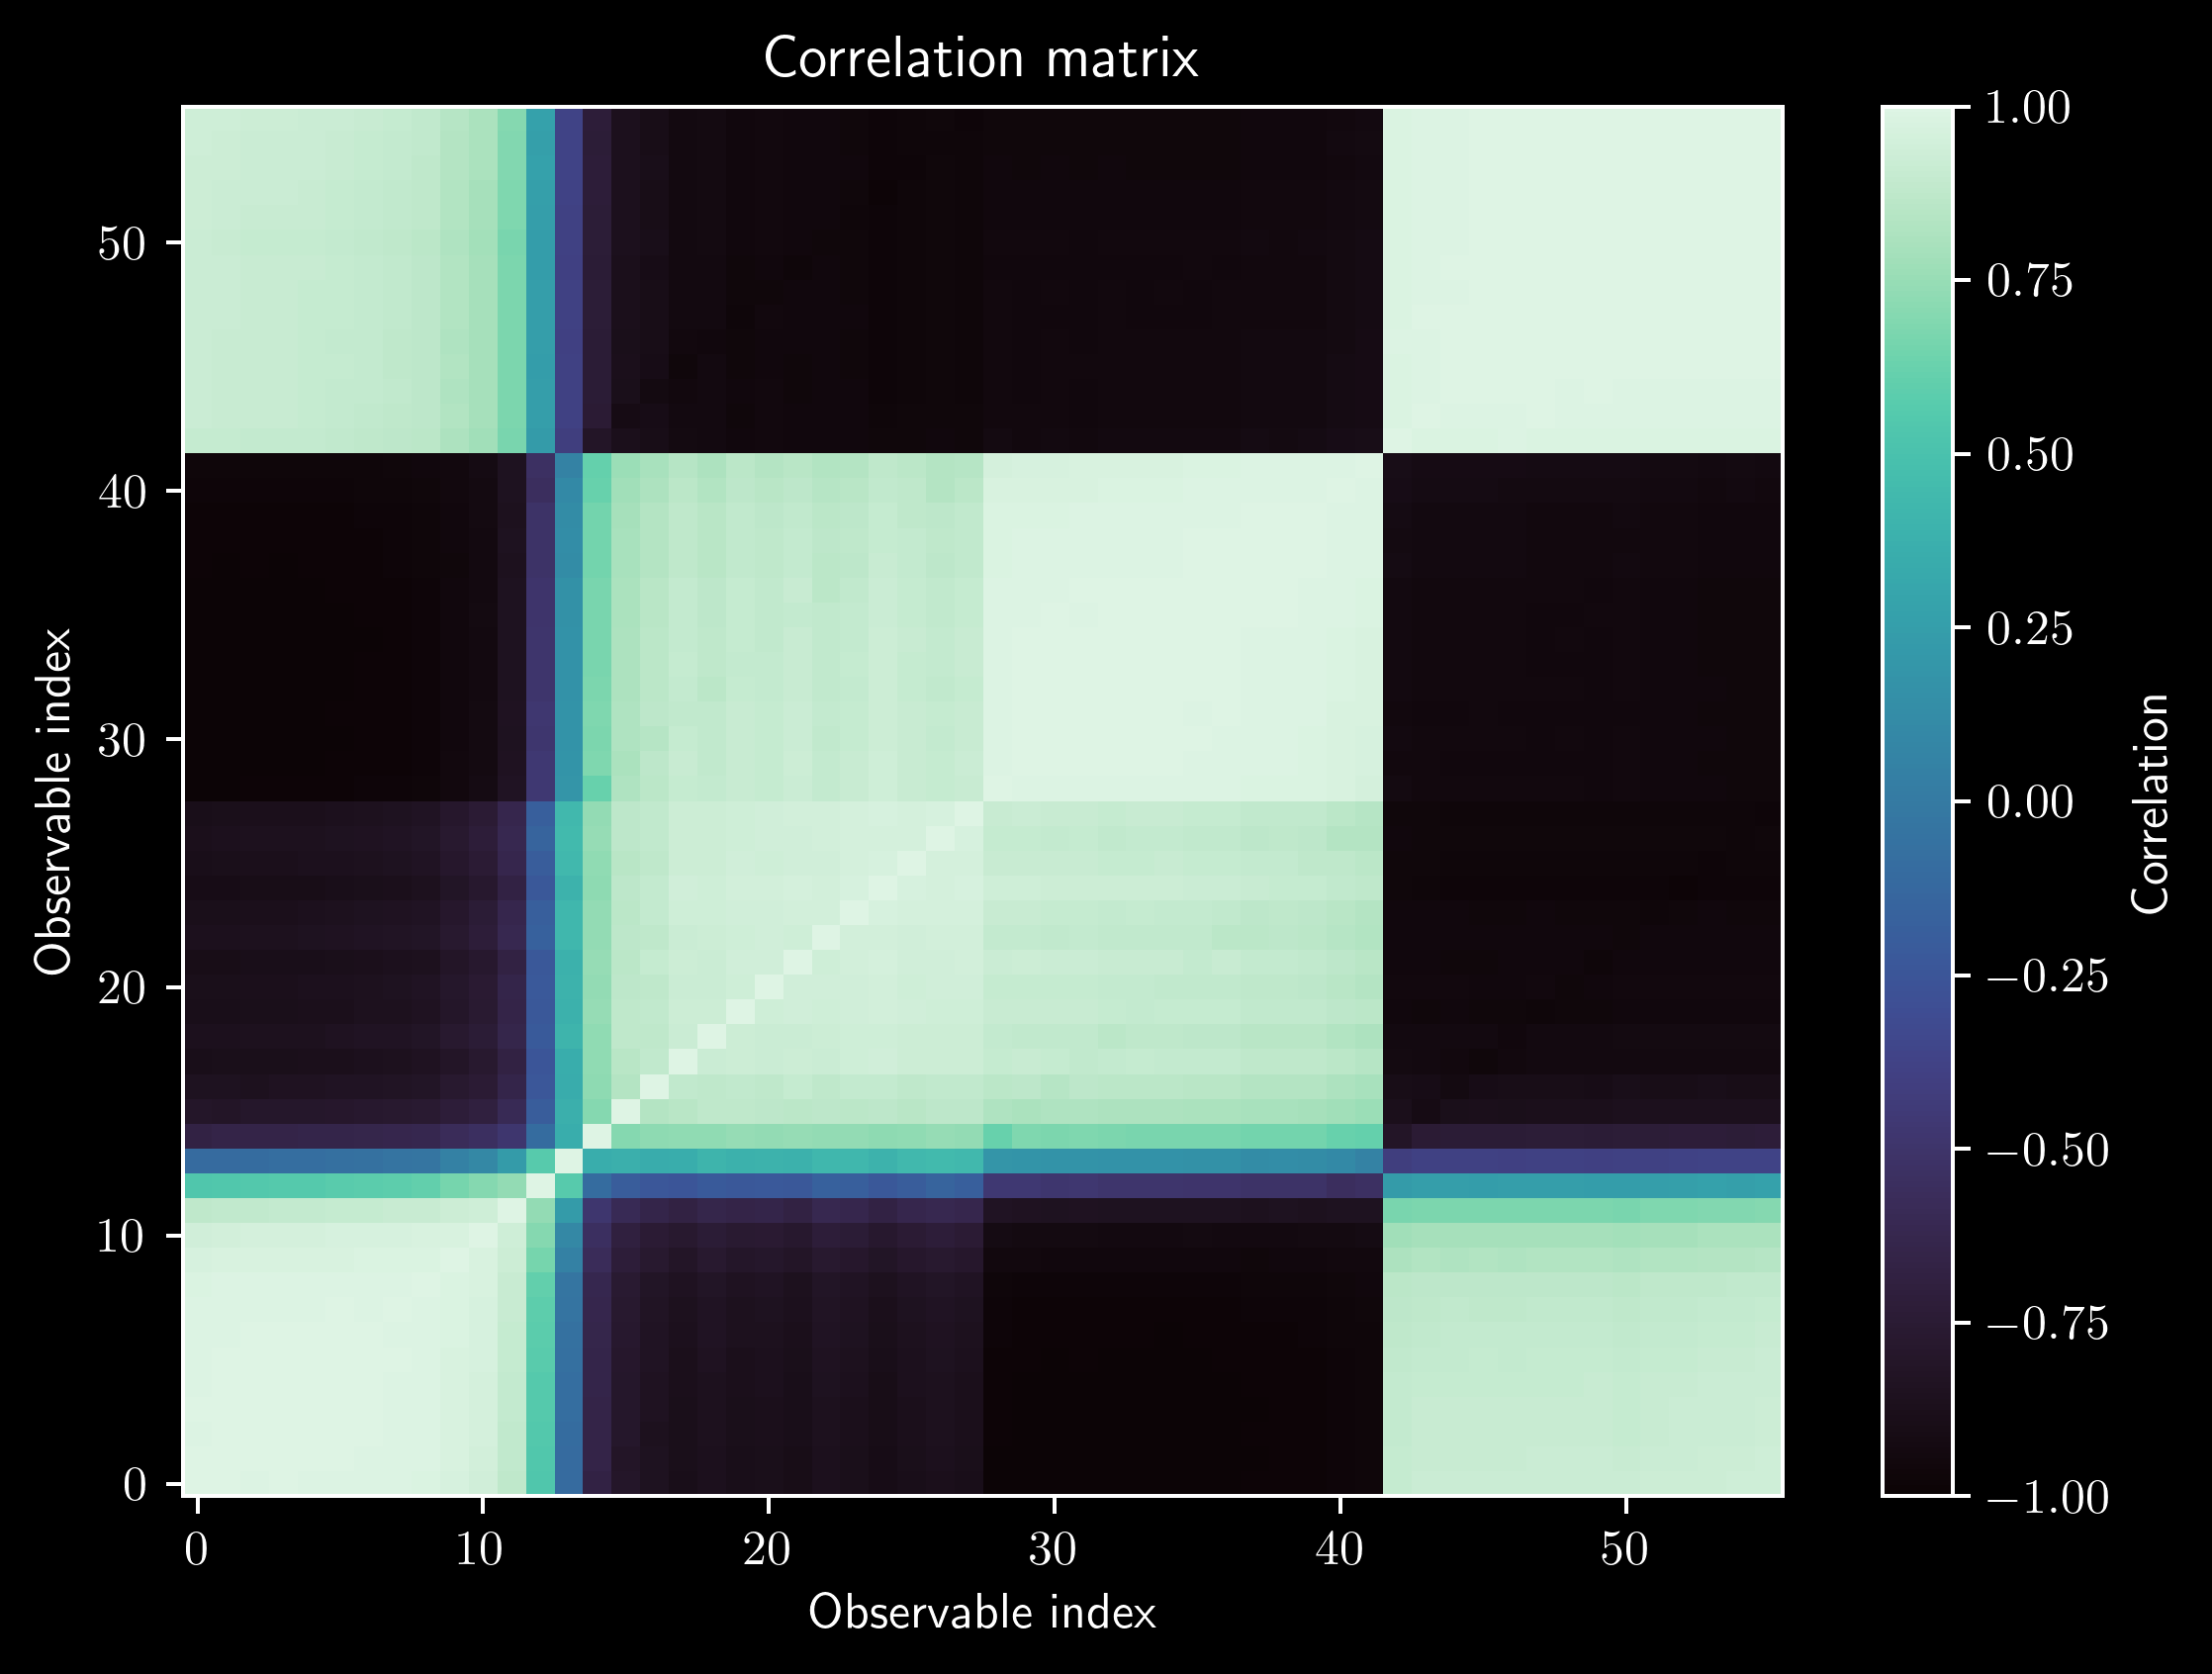

In [33]:
C = np.cov(O_fid_all, rowvar=False)
C.shape

plt.imshow(Corr, vmin=-1, vmax=1, origin='lower', cmap=cmap, aspect='auto')
plt.colorbar(label='Correlation')
plt.xlabel('Observable index')
plt.ylabel('Observable index')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [34]:
N_mocks = O_fid_all.shape[0]
N_obs = O_fid_all.shape[1]

N_mocks, N_obs

(500, 56)

hartlap factor corrects the inverse covariance estimated from a finite number of mocks

 ----> prevents the Fisher constraints from being artificially over-optimistic
 
$$\alpha_H = \frac{N_{\mathrm{mocks}} - N_{\mathrm{observables}} - 2}{N_{\mathrm{mocks}} - 1}$$

$$F = D \, C^{-1} \, D^T$$

$$F_{\alpha_H} = D \, (\alpha_H C^{-1}) \, D^T = \alpha_H F$$

$$\sigma_i \sim \sqrt{(F^{-1})_{ii}}$$

$$F_{\alpha_H}^{-1} = \frac{1}{\alpha_H} F^{-1}$$

In [35]:
alpha = (N_mocks - N_obs - 2) / (N_mocks - 1)
alpha

0.8857715430861723

In [36]:
# Cinv = alpha * np.linalg.inv(C)
Cinv = np.linalg.inv(C)

In [37]:
F = D @ Cinv @ D.T

In [123]:
param_names = ['omega_b', 'omega_cdm', 'n_s', 'sigma8']
F_df = pd.DataFrame(F, index=param_names, columns=param_names)
F_df

,omega_b,omega_cdm,n_s,sigma8
omega_b,1.442729e+08,5.191630e+06,-549030.078358,862648.970550
omega_cdm,5.191630e+06,1.822073e+06,-78503.134408,111025.883183
n_s,-5.490301e+05,-7.850313e+04,348406.061378,35010.276321
sigma8,8.626490e+05,1.110259e+05,35010.276321,196646.628711


In [124]:
param_cov = np.linalg.inv(F)
sigma_params = np.sqrt(np.diag(param_cov))

for name, sig in zip(param_names, sigma_params):
    print(f'{name}: sigma = {sig:.5e}')

omega_b: sigma = 8.86192e-05
omega_cdm: sigma = 7.94214e-04
n_s: sigma = 1.72729e-03
sigma8: sigma = 2.33984e-03


In [125]:
fid_params = {'omega_b': 0.02237,
              'omega_cdm': 0.12000,
              'n_s': 0.96490,
              'sigma8': 0.807952}

In [126]:
theta_fid = np.array([fid_params[p] for p in param_names])

In [127]:
def add_fisher_ellipse(ax, cov2d, mean2d, nsigma=1, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov2d)

    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    width = 2 * nsigma * np.sqrt(eigvals[0])
    height = 2 * nsigma * np.sqrt(eigvals[1])

    ellipse = Ellipse(xy=mean2d, width=width, height=height,
                      angle=angle, fill=True, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

In [116]:
def add_confidence_ellipse(ax, cov2d, mean2d, level=0.68, **kwargs):
    """
    68.3% -> Delta chi2 = 2.30
    95.4% -> Delta chi2 = 6.17
    99.7% -> Delta chi2 = 11.8
    """
    delta_chi2 = {0.68: 2.30,
                  0.683: 2.30,
                  0.95: 5.99,
                  0.954: 6.17,
                  0.99: 9.21,
                  0.997: 11.8}

    scale = np.sqrt(delta_chi2[level])
    eigvals, eigvecs = np.linalg.eigh(cov2d)

    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    width = 2 * scale * np.sqrt(eigvals[0])
    height = 2 * scale * np.sqrt(eigvals[1])

    ellipse = Ellipse(xy=mean2d, width=width,
                      height=height, angle=angle,
                      fill=True, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

In [82]:
p1 = 'omega_cdm'
p2 = 'sigma8'

l1 = r'$\omega_{\mathrm{cdm}}$'
l2 = r'$\sigma_8$'

In [83]:
i = param_names.index(p1)
j = param_names.index(p2)

In [84]:
cov2d = param_cov[np.ix_([i, j], [i, j])]
mean2d = theta_fid[[i, j]]

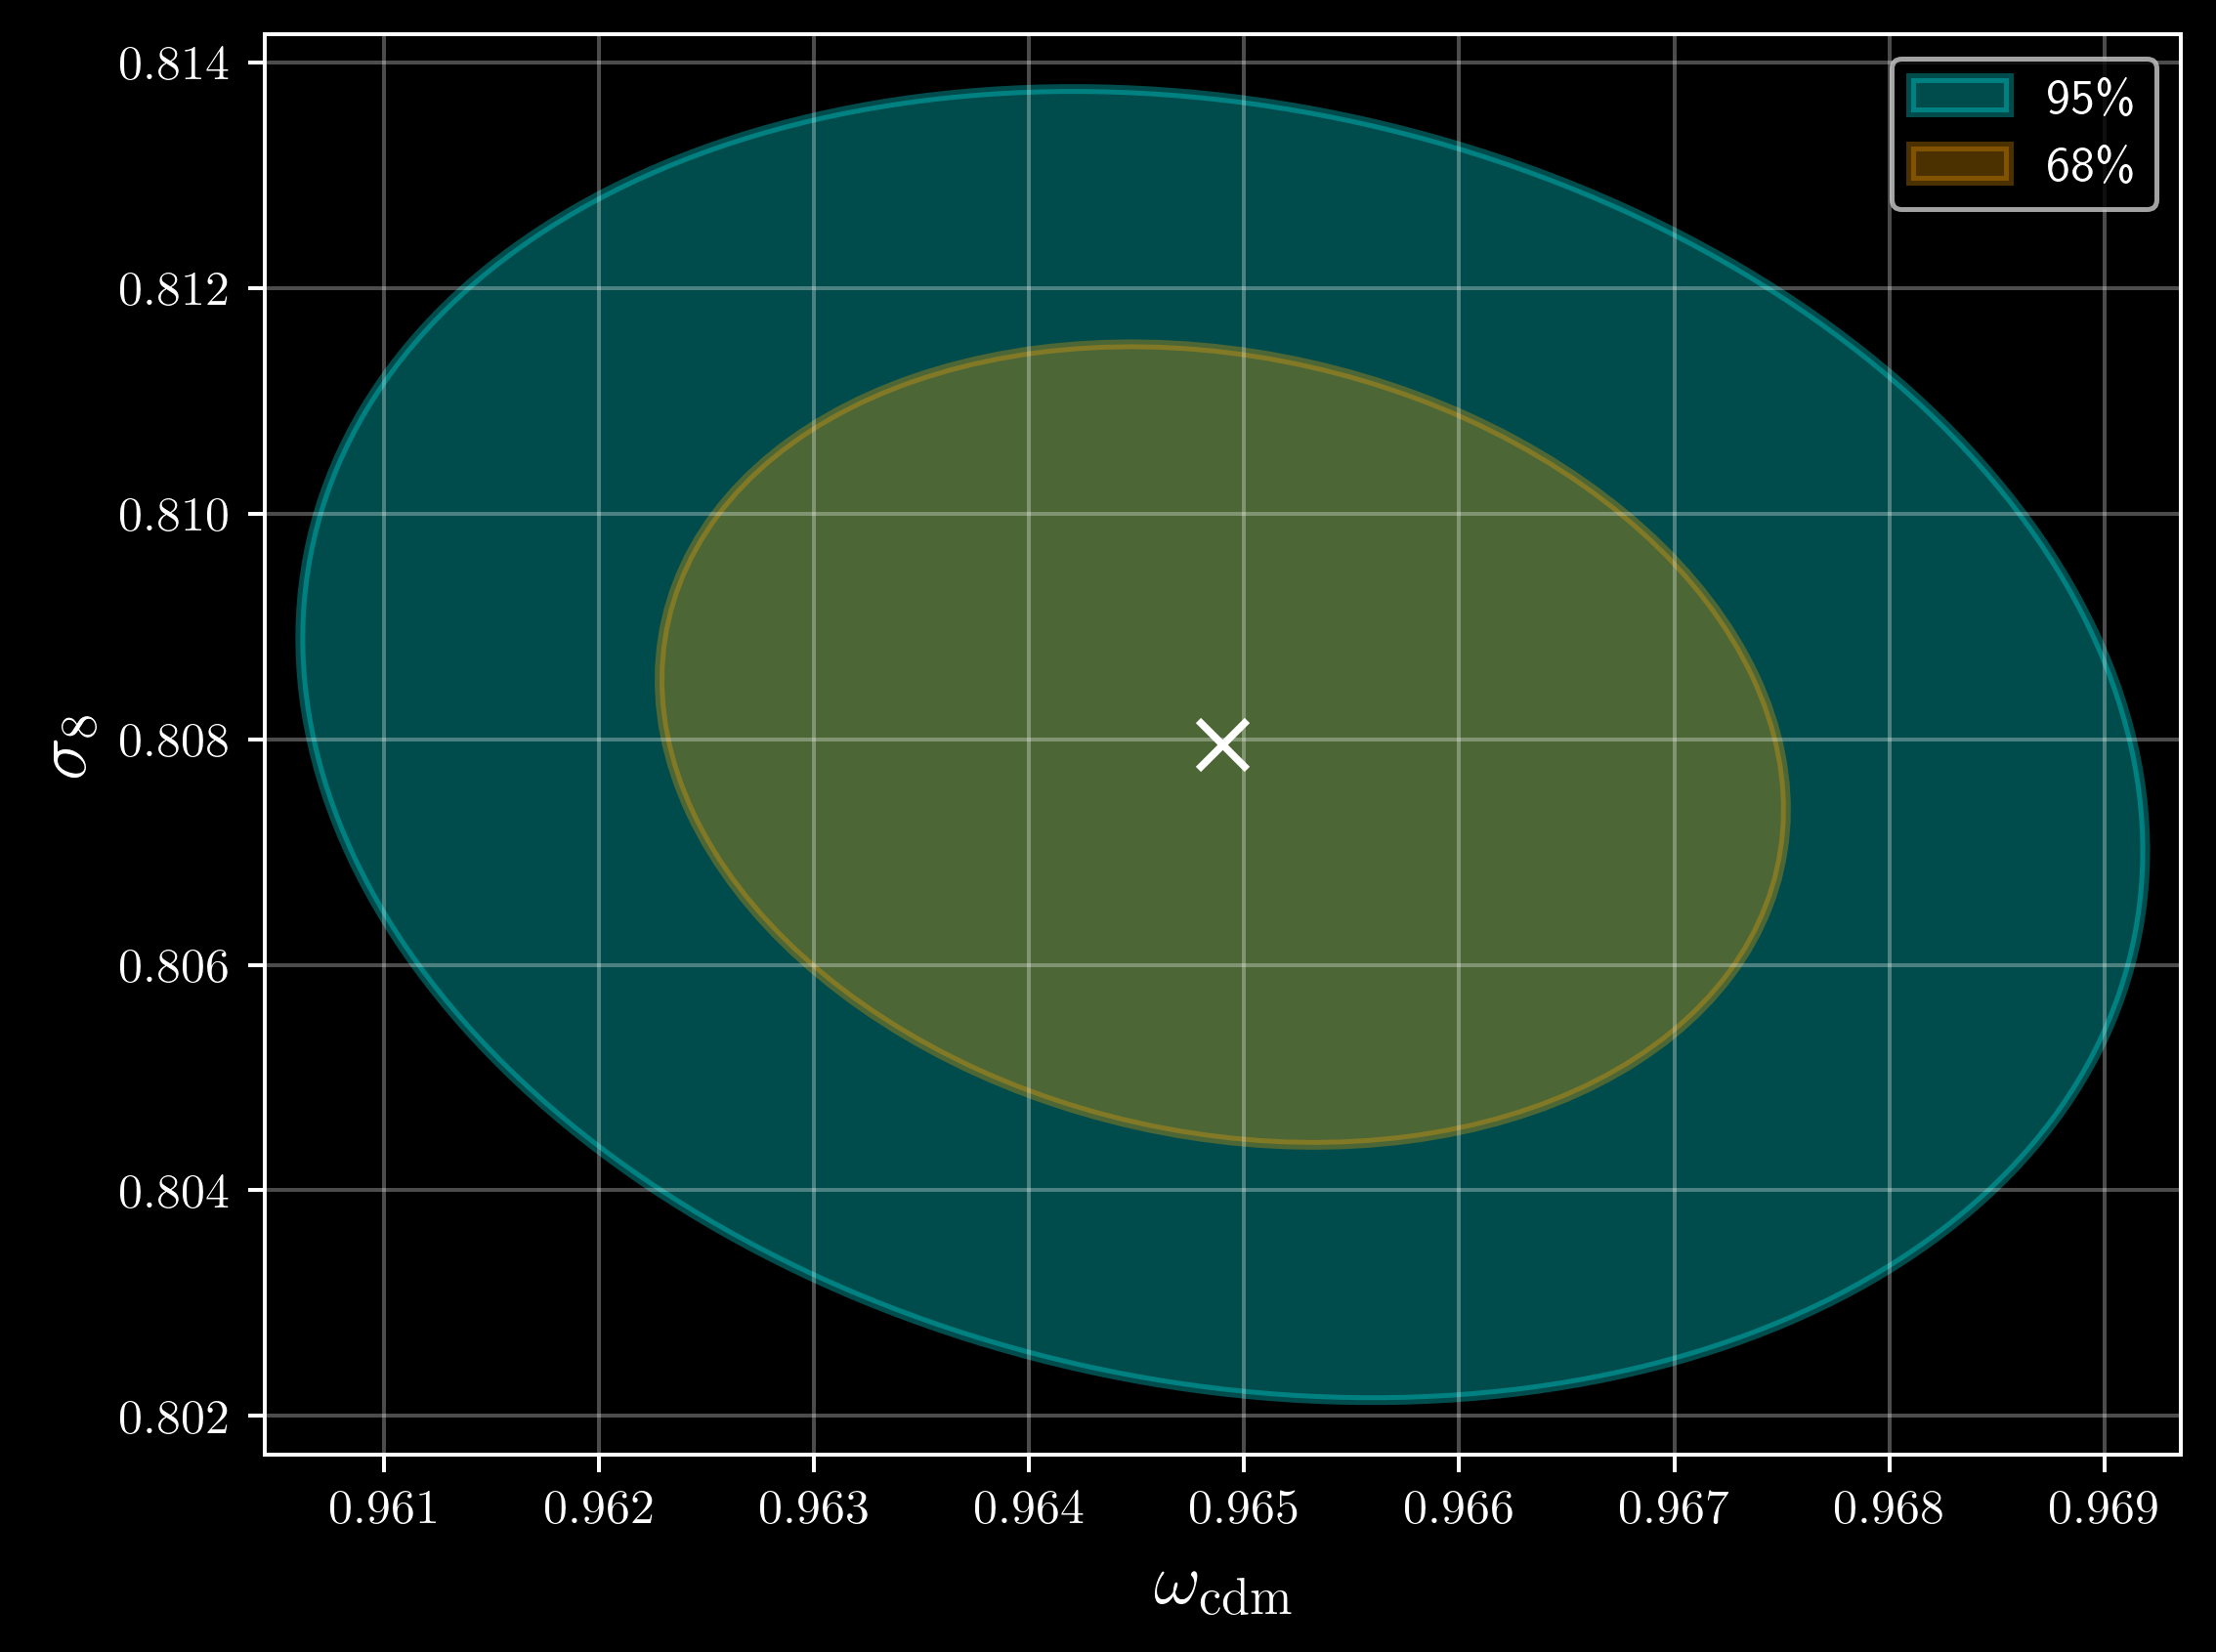

In [96]:
fig, ax = plt.subplots()

add_confidence_ellipse(ax, cov2d, mean2d,
                       level=0.954, lw=2, #ls='--',
                       label=r'95\%', color='cyan', alpha=0.3)
add_confidence_ellipse(ax, cov2d, mean2d,
                       level=0.68, lw=2, label=r'68\%',
                       color='orange', alpha=0.3)

ax.scatter(mean2d[0], mean2d[1], marker='x', s=100, c='white')

ax.set_xlabel(l1, fontsize=15)
ax.set_ylabel(l2, fontsize=15)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
npar = len(param_names)

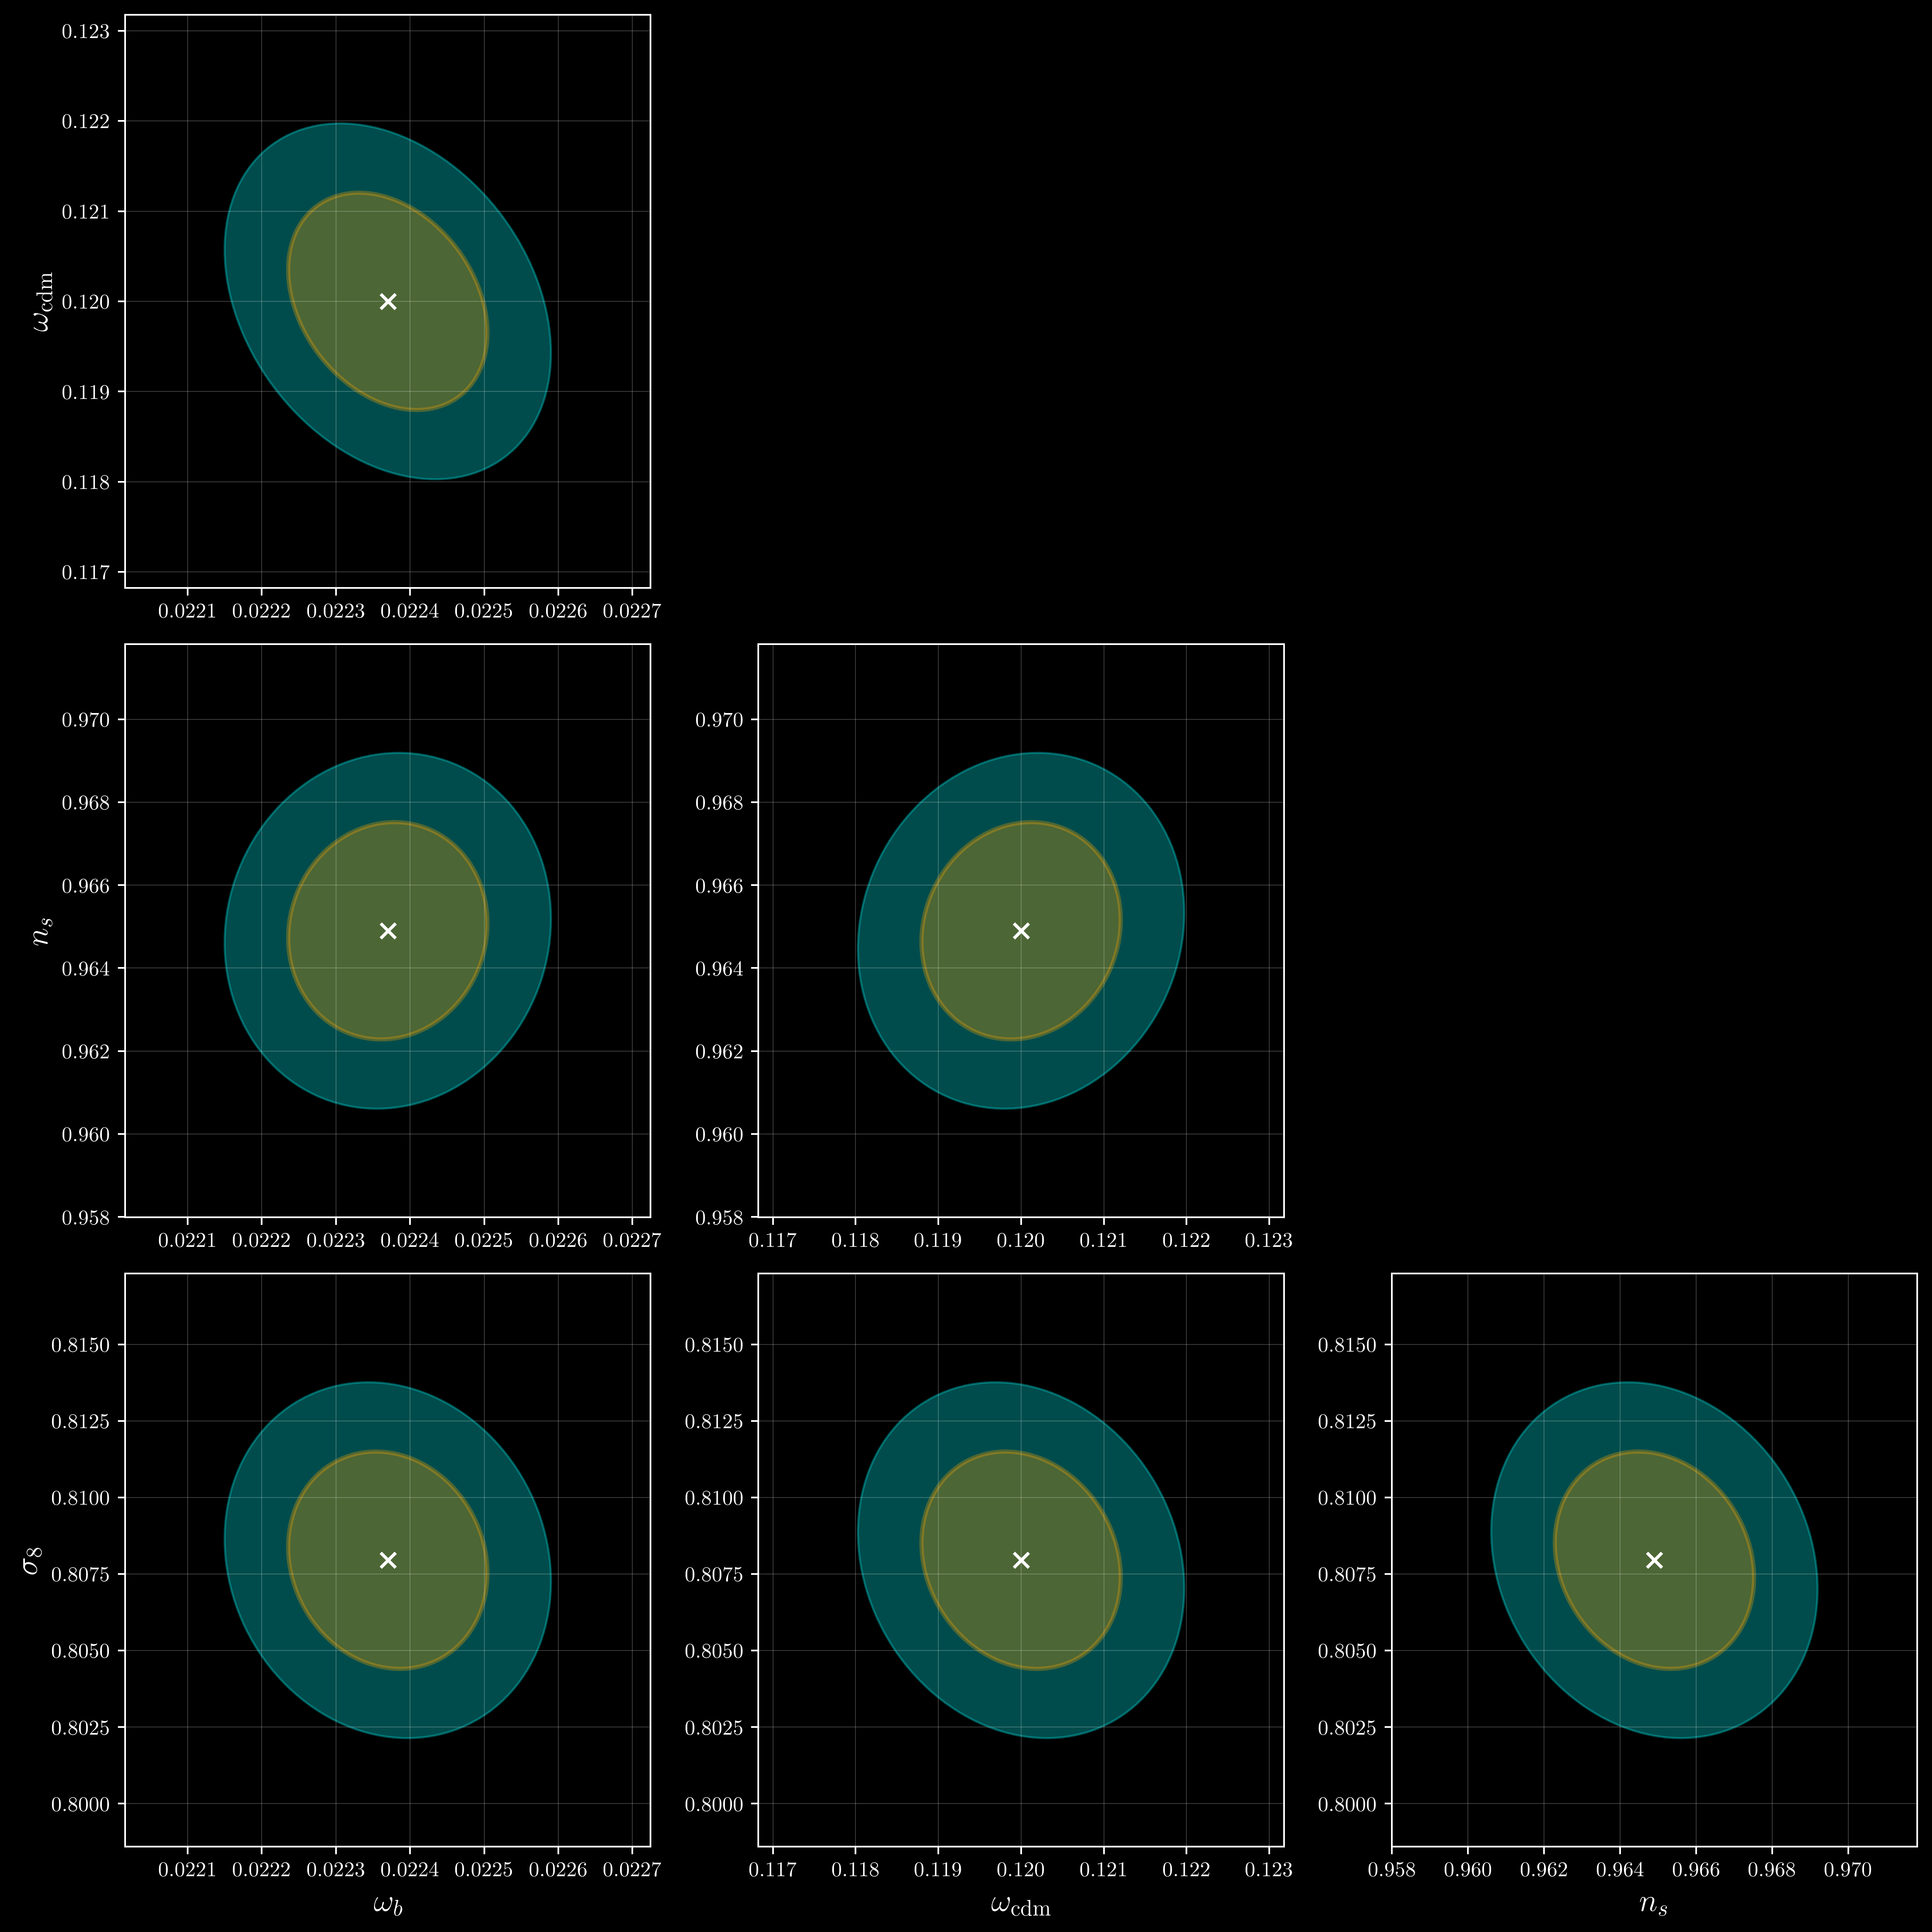

In [108]:
fig, axes = plt.subplots(npar-1, npar-1, figsize=(3.2*npar, 3.2*npar),
                        sharex=False, sharey=False)

if npar == 1:
    axes = np.array([[axes]])

for row in range(npar - 1):
    for col in range(npar - 1):

        ax = axes[row, col]

        i = row + 1
        j = col

        # Upper triangle: turn off
        if j >= i:
            ax.axis('off')
            continue

        cov2d = param_cov[np.ix_([j, i], [j, i])]
        mean2d = theta_fid[[j, i]]

        add_confidence_ellipse(ax, cov2d, mean2d, level=0.954, color='cyan', alpha=0.3)
        add_confidence_ellipse(ax, cov2d, mean2d, level=0.68, lw=2, label=r'68\%',
                       color='orange', alpha=0.3)

        ax.scatter(mean2d[0], mean2d[1], marker='x', s=50, c='white')

        sig_x = np.sqrt(param_cov[j, j])
        sig_y = np.sqrt(param_cov[i, i])

        ax.set_xlim(mean2d[0] - 4 * sig_x, mean2d[0] + 4 * sig_x)
        ax.set_ylim(mean2d[1] - 4 * sig_y, mean2d[1] + 4 * sig_y)

        ax.grid(alpha=0.3, lw=0.3)

        if row == npar - 2:
            ax.set_xlabel(param_names[j], fontsize=15)

        if col == 0:
            ax.set_ylabel(param_names[i], fontsize=15)

plt.tight_layout()
plt.show()

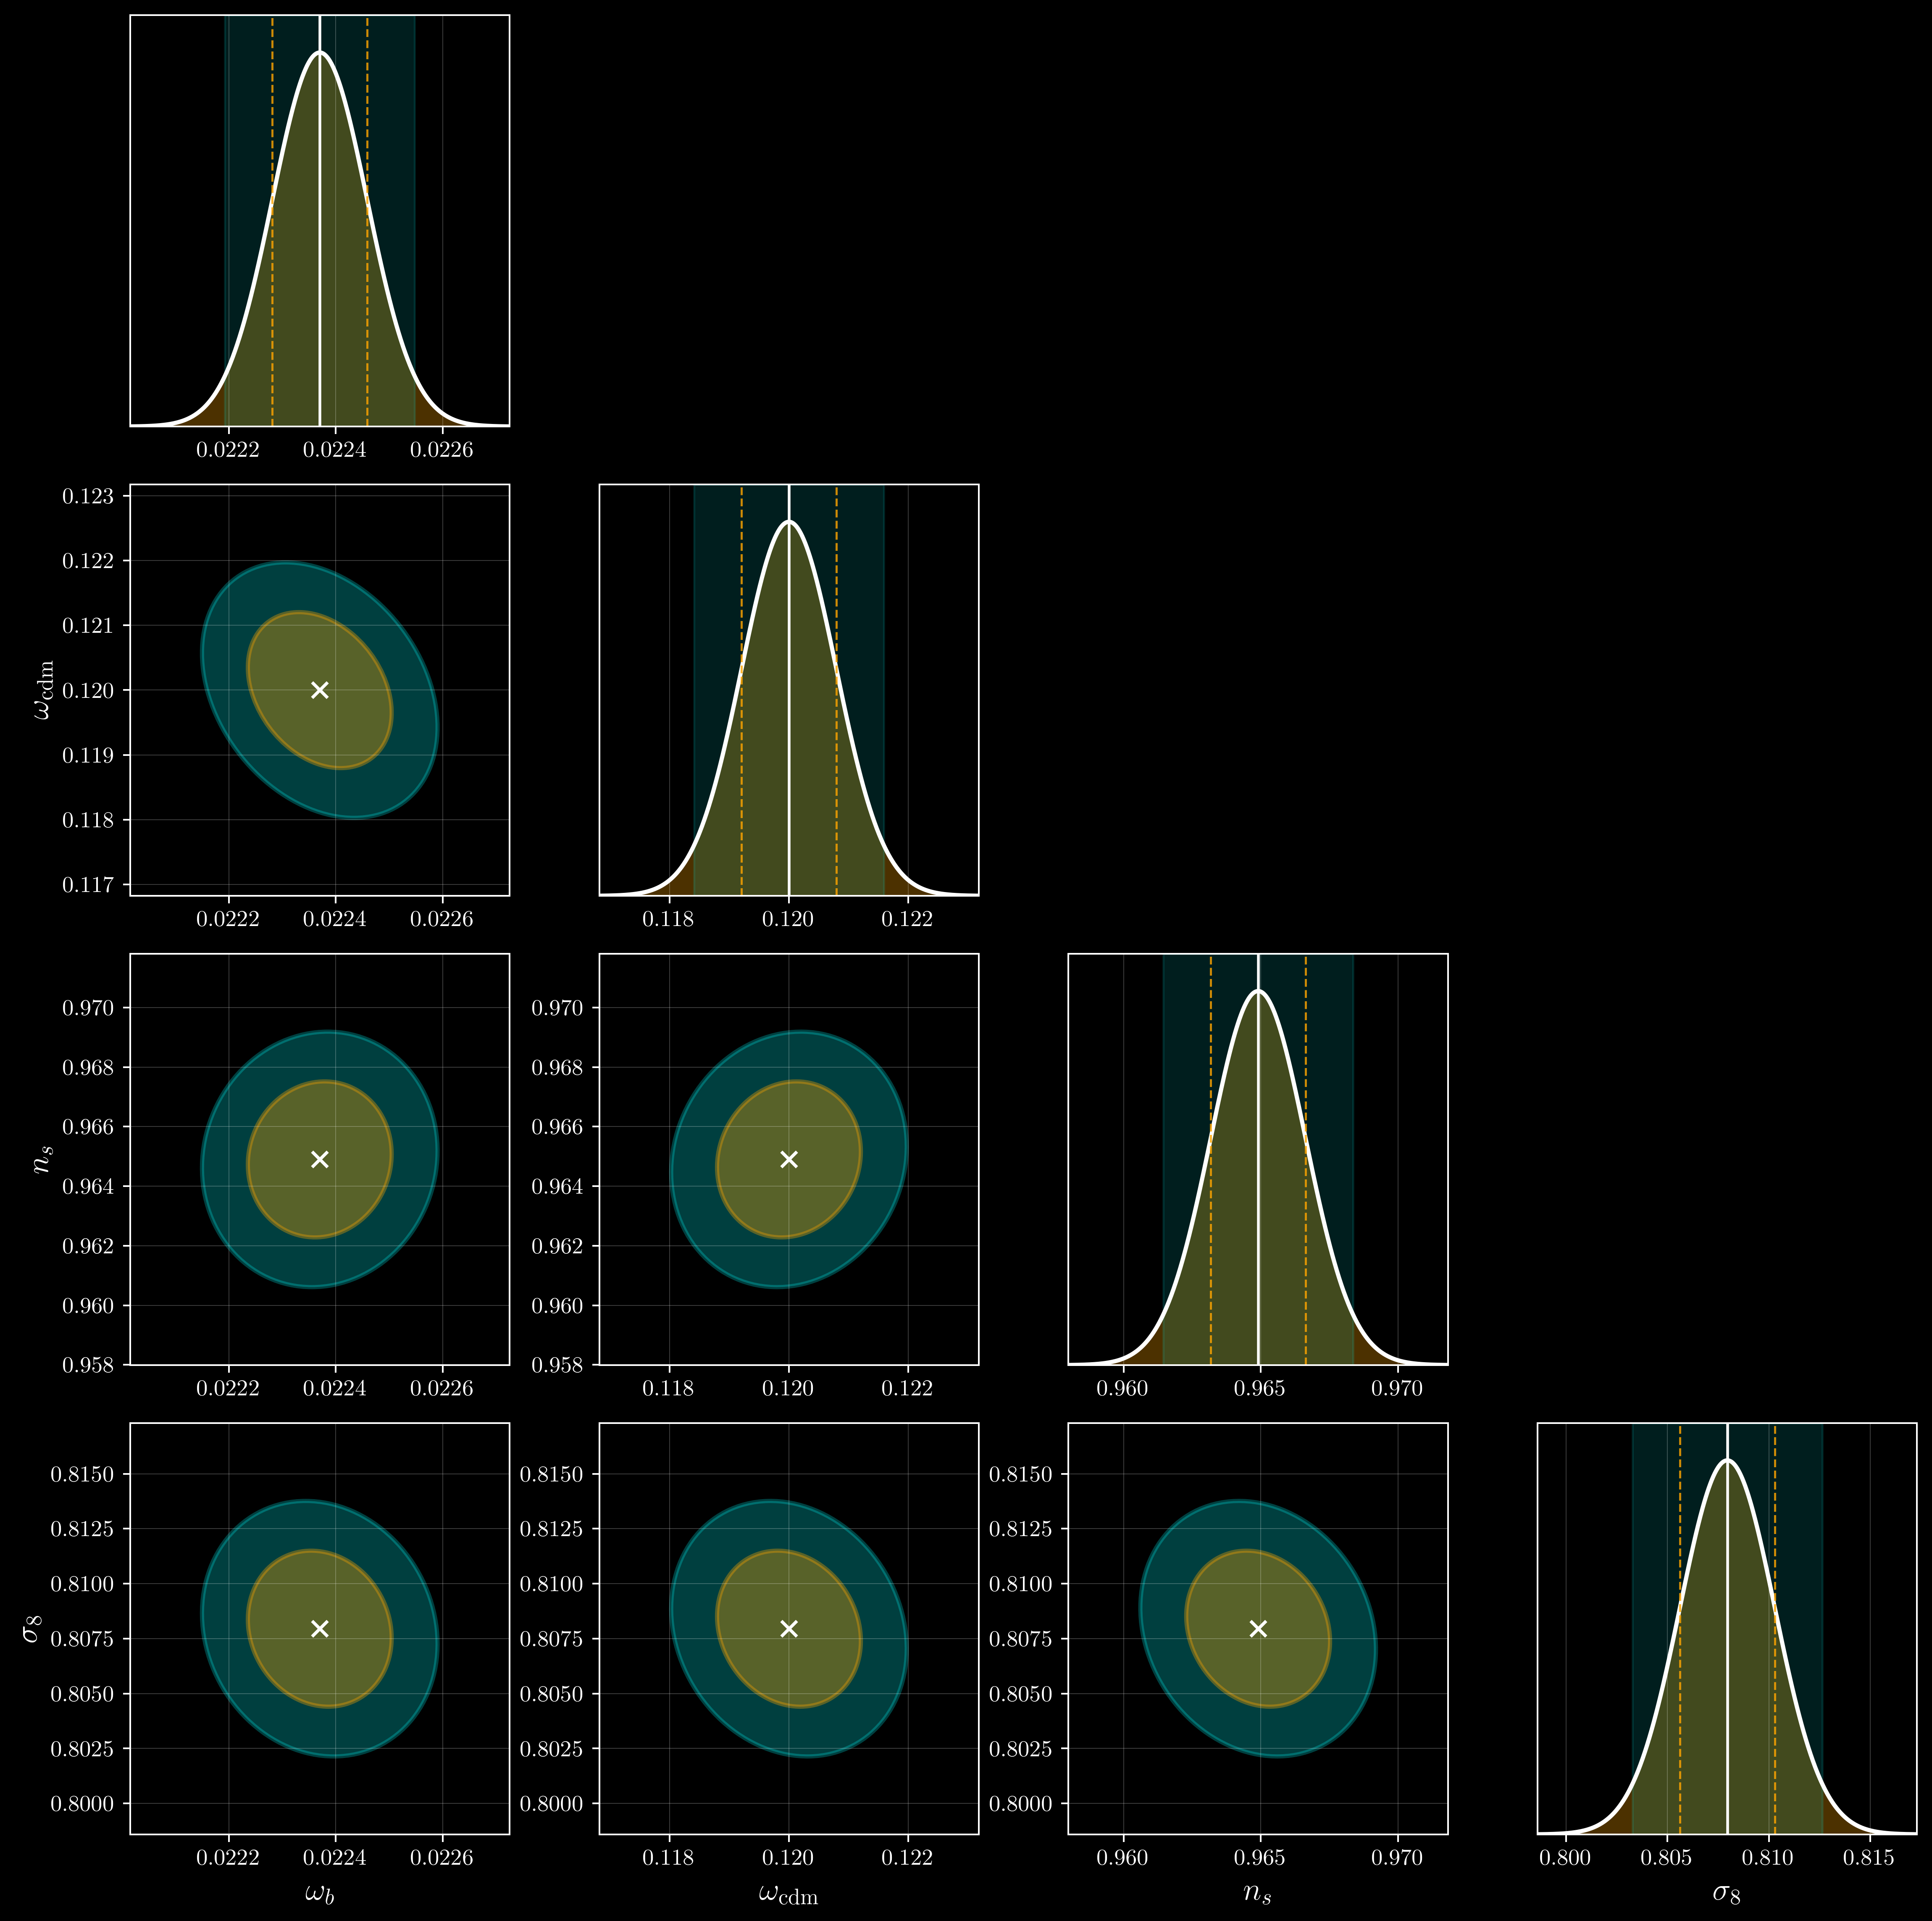

In [132]:
fig, axes = plt.subplots(npar, npar, figsize=(3.2*npar, 3.2*npar))

if npar == 1:
    axes = np.array([[axes]])

for row in range(npar):
    for col in range(npar):

        ax = axes[row, col]

        if col > row:
            ax.axis('off')
            continue

        if row == col:
            mu = theta_fid[row]
            sig = np.sqrt(param_cov[row, row])

            x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)

            y = np.exp(-0.5 * ((x - mu) / sig)**2)
            y /= y.max()

            ax.plot(x, y, color='white', lw=2)
            ax.fill_between(x, 0, y, color='orange', alpha=0.30)
            
            ax.axvline(mu, color='white', lw=1.3)
            
            ax.axvline(mu - sig, color='orange', lw=1, ls='--', alpha=0.8)
            ax.axvline(mu + sig, color='orange', lw=1, ls='--', alpha=0.8)

            ax.axvspan(mu-2*sig, mu+2*sig, color='cyan', alpha=0.12)

            ax.set_xlim(mu - 4 * sig, mu + 4 * sig)
            ax.set_ylim(0, 1.1)
            ax.set_yticks([])
            
            # ax.text(0.06, 0.82, param_names[row],
            #         transform=ax.transAxes, fontsize=15,
            #         color='white')
            ax.grid(alpha=0.3, lw=0.3)

        else:
            i = row
            j = col

            cov2d = param_cov[np.ix_([j, i], [j, i])]
            mean2d = theta_fid[[j, i]]

            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.954,
                                   facecolor='cyan',
                                   edgecolor='cyan',
                                   alpha=0.25, lw=2)
            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.68,
                                   facecolor='orange',
                                   edgecolor='orange',
                                   alpha=0.35, lw=2)

            ax.scatter(mean2d[0], mean2d[1], marker='x',
                       s=55, c='white', lw=1.5)

            sig_x = np.sqrt(param_cov[j, j])
            sig_y = np.sqrt(param_cov[i, i])

            ax.set_xlim(mean2d[0] - 4 * sig_x,
                        mean2d[0] + 4 * sig_x)
            ax.set_ylim(mean2d[1] - 4 * sig_y,
                        mean2d[1] + 4 * sig_y)

            ax.grid(alpha=0.3, lw=0.3)

        if row == npar - 1:
            ax.set_xlabel(param_names[col], fontsize=15)
        if col == 0 and row > 0:
            ax.set_ylabel(param_names[row], fontsize=15)
        ax.tick_params(axis='both', labelsize=11)


plt.tight_layout()
plt.savefig('conf_ellip.png', dpi=360, bbox_inches='tight')
plt.show()

## Very noisy -> better to use the mean of dif hod?

$$\left.\frac{\partial \mathcal{O}}{\partial \omega_b}\right|_{\mathrm{hod000}}= \frac{\mathcal{O}_{c100,\mathrm{h000}}-\mathcal{O}_{c101,\mathrm{h000}}}
{\omega_{b,c100}-\omega_{b,c101}}$$

$$\left.\frac{\partial \mathcal{O}}{\partial \omega_b}\right|_{\mathrm{hod001}}=\frac{\mathcal{O}_{c100,\mathrm{h001}}-\mathcal{O}_{c101,\mathrm{h001}}} {\omega_{b,c100}-\omega_{b,c101}}$$

$$\frac{\partial \mathcal{O}}{\partial \omega_b} = \left\langle \left.
 \frac{\partial \mathcal{O}}{\partial \omega_b}
\right|_{\mathrm{hod}}
\right\rangle_{\mathrm{HOD}}$$

all pairs (c100-c101, c102-c103, c104-c105, c112-c113) have dif common hods

In [147]:
base_path = Path('/pscratch/sd/v/vtorresg/marked_pk')

In [148]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hod_id = p.name.replace('hod', '')
            hods.append(hod_id)
            
    return sorted(hods)


def get_common_hods(cid_plus, cid_minus):
    hods_plus = set(get_available_hods(cid_plus))
    hods_minus = set(get_available_hods(cid_minus))
    common = sorted(hods_plus & hods_minus)
    return common

In [149]:
hods_wb = get_common_hods('100', '101')
hods_wcdm = get_common_hods('102', '103')
hods_ns = get_common_hods('104', '105')
hods_s8 = get_common_hods('112', '113')

In [150]:
pair_hods = {('100', '101'): hods_wb,
             ('102', '103'): hods_wcdm,
             ('104', '105'): hods_ns,
             ('112', '113'): hods_s8}

In [151]:
for pair, hods in pair_hods.items():
    print(pair, len(hods))

('100', '101') 290
('102', '103') 275
('104', '105') 274
('112', '113') 305


In [152]:
def load_pk_dataframe(cid, hod):
    filename = (base_path / f'c{cid}' / f'hod{hod}' /
                f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{hod}_N256.csv')
    return pd.read_csv(filename)

In [153]:
def build_common_mask_for_pair(cid_plus, cid_minus, hod):
    df_plus = load_pk_dataframe(cid_plus, hod)
    df_minus = load_pk_dataframe(cid_minus, hod)
    
    mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
    mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
    
    return mask

In [154]:
def build_observable_from_df(df, mask):
    return df.loc[mask, obs_cols].to_numpy().T.ravel()

a fixed range in $k$

In [155]:
kmin = 0.02
kmax = 0.20

In [156]:
def compute_pair_derivatives(cid_plus, cid_minus, hods, delta_theta,
                                  kmin=kmin, kmax=kmax):
    dO_all = []
    k_ref = None
    
    for hod in hods:
        df_plus = load_pk_dataframe(cid_plus, hod)
        df_minus = load_pk_dataframe(cid_minus, hod)
        
        mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
        mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
        mask &= df_plus['k_h_mpc'].between(kmin, kmax)
        
        O_plus = build_observable_from_df(df_plus, mask)
        O_minus = build_observable_from_df(df_minus, mask)
        
        dO = (O_plus - O_minus) / delta_theta
        dO_all.append(dO)
        
        if k_ref is None:
            k_ref = df_plus.loc[mask, 'k_h_mpc'].to_numpy()
    
    dO_all = np.array(dO_all)
    dO_mean = np.mean(dO_all, axis=0)
    dO_err = np.std(dO_all, axis=0) / np.sqrt(len(dO_all))
    
    return dO_mean, dO_err, dO_all, k_ref

In [157]:
def compute_derivative_from_mean_observable(cid_plus, cid_minus, hods, delta_theta,
                                            kmin=kmin, kmax=kmax):
    O_plus_all = []
    O_minus_all = []
    k_ref = None

    for hod in hods:
        df_plus = load_pk_dataframe(cid_plus, hod)
        df_minus = load_pk_dataframe(cid_minus, hod)

        mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
        mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
        mask &= df_plus['k_h_mpc'].between(kmin, kmax)

        k_this = df_plus.loc[mask, 'k_h_mpc'].to_numpy()

        if k_ref is None:
            k_ref = k_this
        else:
            if len(k_this) != len(k_ref) or not np.allclose(k_this, k_ref):
                raise ValueError(f'k grid mismatch for hod{hod}')

        O_plus = build_observable_from_df(df_plus, mask)
        O_minus = build_observable_from_df(df_minus, mask)

        O_plus_all.append(O_plus)
        O_minus_all.append(O_minus)

    O_plus_all = np.array(O_plus_all)
    O_minus_all = np.array(O_minus_all)

    O_plus_mean = np.mean(O_plus_all, axis=0)
    O_minus_mean = np.mean(O_minus_all, axis=0)

    dO = (O_plus_mean - O_minus_mean) / delta_theta

    return dO, O_plus_mean, O_minus_mean, O_plus_all, O_minus_all, k_ref

In [158]:
steps = {'omega_b': delta_wb,
         'omega_cdm': delta_wcdm,
         'n_s': delta_ns,
         'sigma8': delta_sigma8}

In [159]:
dO_dwb, O_100_mean, O_101_mean, O_100_all, O_101_all, k = compute_derivative_from_mean_observable('100', '101', hods_wb, steps['omega_b'])
dO_dwb.shape

(56,)

In [160]:
dO_dwcdm, O_102_mean, O_103_mean, O_102_all, O_103_all, _ = compute_derivative_from_mean_observable('102', '103', hods_wcdm, steps['omega_cdm'])
dO_dwcdm.shape

(56,)

In [161]:
dO_dns, O_104_mean, O_105_mean, O_104_all, O_105_all, _ = compute_derivative_from_mean_observable('104', '105', hods_ns, steps['n_s'])
dO_dns.shape

(56,)

In [162]:
dO_dsigma8, O_112_mean, O_113_mean, O_112_all, O_113_all, _ = compute_derivative_from_mean_observable('112', '113', hods_s8, steps['sigma8'])
dO_dsigma8.shape

(56,)

In [163]:
D = np.vstack([dO_dwb, dO_dwcdm, dO_dns, dO_dsigma8])
D.shape

(4, 56)

In [164]:
derivative_means = {'omega_b': dO_dwb,
                    'omega_cdm': dO_dwcdm,
                    'n_s': dO_dns,
                    'sigma8': dO_dsigma8}

In [165]:
def derivative_error_from_observable_scatter(O_plus_all, O_minus_all, delta_theta):
    N_plus = O_plus_all.shape[0]
    N_minus = O_minus_all.shape[0]

    var_plus_mean = np.var(O_plus_all, axis=0, ddof=1) / N_plus
    var_minus_mean = np.var(O_minus_all, axis=0, ddof=1) / N_minus

    dO_err = np.sqrt(var_plus_mean + var_minus_mean) / np.abs(delta_theta)

    return dO_err

In [166]:
dO_dwb_err = derivative_error_from_observable_scatter(O_100_all, O_101_all, delta_wb)
dO_dwcdm_err = derivative_error_from_observable_scatter(O_102_all, O_103_all, delta_wcdm)
dO_dns_err = derivative_error_from_observable_scatter(O_104_all, O_105_all, delta_ns)
dO_dsigma8_err = derivative_error_from_observable_scatter(O_112_all, O_113_all, delta_sigma8)

In [167]:
derivative_errs = {'omega_b': dO_dwb_err,
                   'omega_cdm': dO_dwcdm_err,
                   'n_s': dO_dns_err,
                   'sigma8': dO_dsigma8_err}

In [168]:
Nk = len(k)

In [169]:
# for j, par in enumerate(derivative_means):
#     dO = derivative_means[par]
#     err = derivative_errs[par]
    
#     plt.figure(figsize=(7, 5))
    
#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         yerr = err[i*Nk:(i+1)*Nk]
        
#         plt.plot(k, y, label=c)
#         plt.fill_between(k, y - yerr, y + yerr, alpha=0.2)
    
#     plt.axhline(0, ls='--', color='white', alpha=0.5)
#     plt.grid(lw=0.3, alpha=0.25)
#     plt.xscale('log')
    
#     plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     plt.ylabel(rf'$\partial O / \partial ${param_names[j]}')
    
#     plt.title(f'Mean derivative over HODs')
    
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f'./plots/deriv/deriv_mean_hod_{j}.png', dpi=360)
#     plt.show()

In [170]:
# fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True)

# for j, (par, ax) in enumerate(zip(derivative_means.keys(), axes)):
#     dO = derivative_means[par]
#     err = derivative_errs[par]

#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         yerr = err[i*Nk:(i+1)*Nk]

#         ax.plot(k, y, label=c)
#         ax.fill_between(k, y - yerr, y + yerr, alpha=0.2)

#     ax.axhline(0, ls='--', color='white', alpha=0.5)
#     ax.grid(lw=0.3, alpha=0.25)
#     ax.set_xscale('log')

#     ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     ax.set_title(param_names[j], fontsize=16)

# axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=len(classes),
#            bbox_to_anchor=(0.5, 1.05))

# fig.suptitle('Mean derivative over HODs', y=1.12)

# plt.tight_layout()
# plt.savefig('./plots/deriv/deriv_mean_hod_all_params.png', dpi=360, bbox_inches='tight')
# plt.show()

In [171]:
plot_params = ['omega_b', 'omega_cdm', 'n_s', 'sigma8']

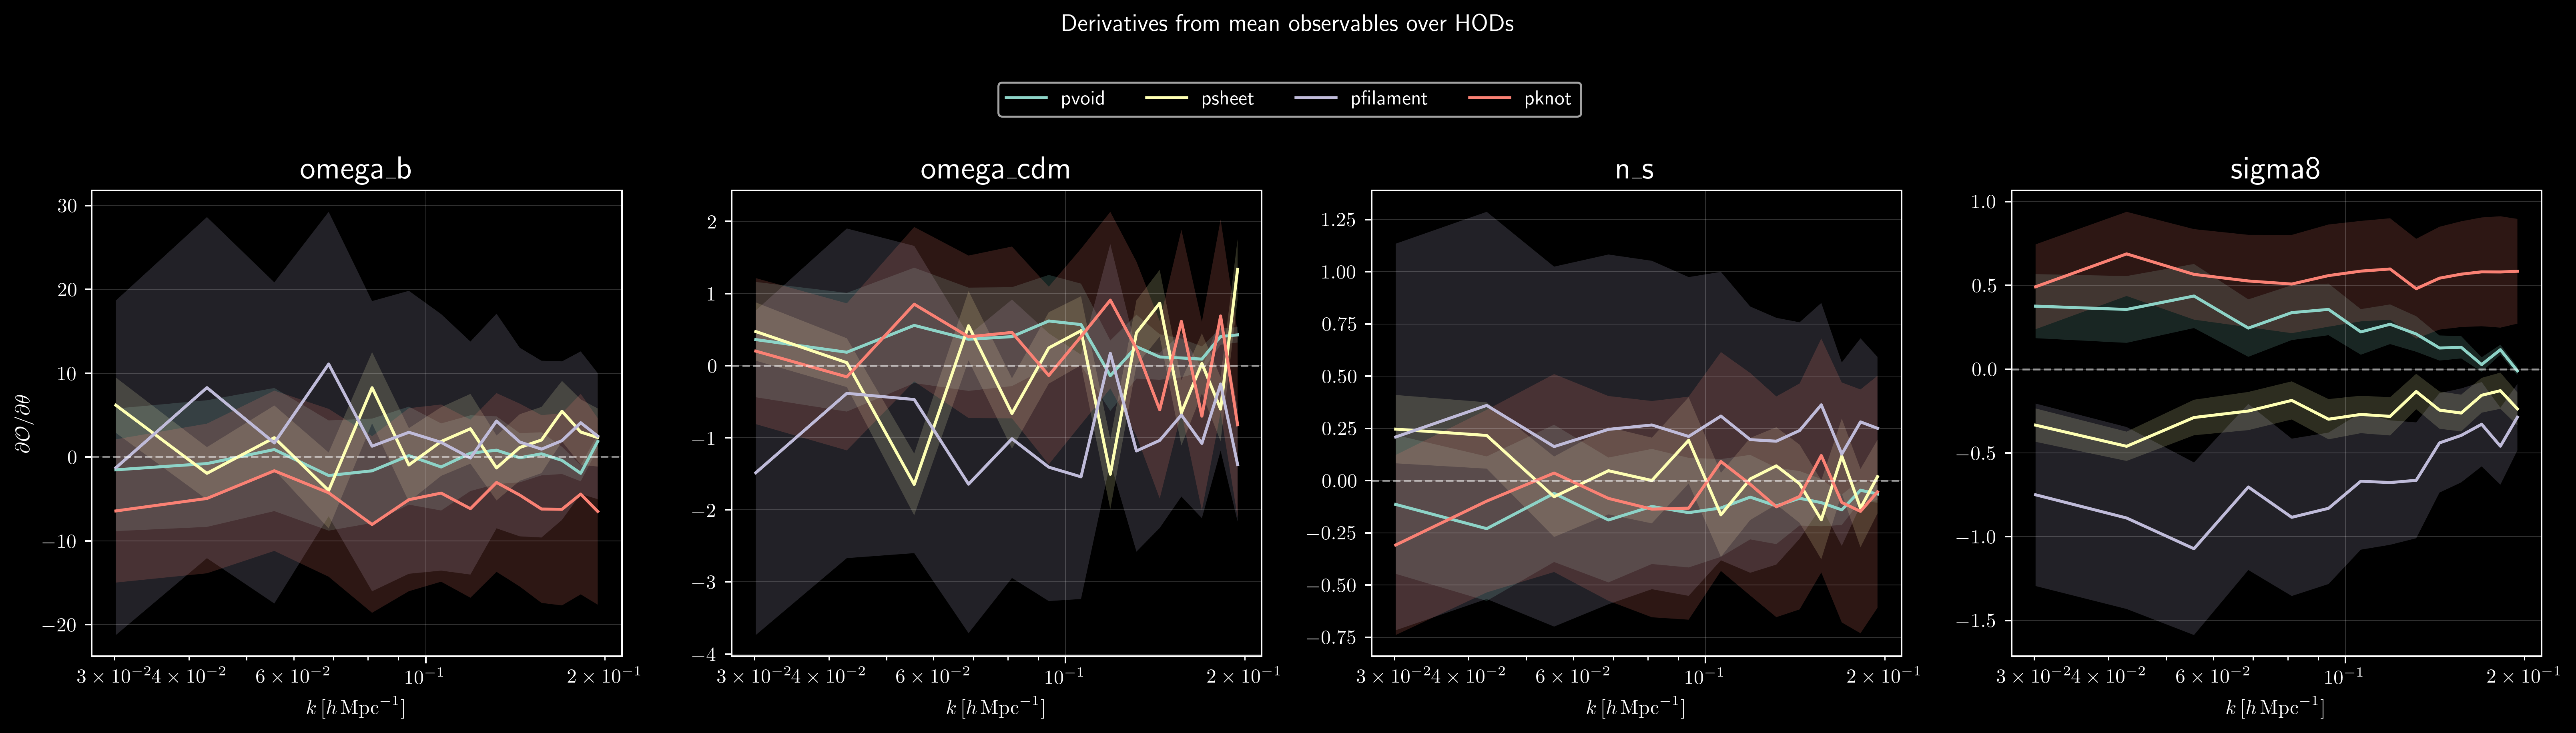

In [172]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True)

for j, par in enumerate(plot_params):
    ax = axes[j]

    dO = derivative_means[par]
    err = derivative_errs[par]

    for i, c in enumerate(classes):
        sl = slice(i * Nk, (i + 1) * Nk)

        y = dO[sl]
        yerr = err[sl]

        ax.plot(k, y, lw=1.5, label=c)
        ax.fill_between(k, y - yerr, y + yerr, alpha=0.18)

    ax.axhline(0, ls='--', color='white', alpha=0.5, lw=1.0)
    ax.grid(lw=0.3, alpha=0.25)
    ax.set_xscale('log')

    ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
    ax.set_title(param_names[j], fontsize=16)

axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(classes), bbox_to_anchor=(0.5, 1.03))

fig.suptitle(r'Derivatives from mean observables over HODs', y=1.12)

fig.tight_layout()
# fig.savefig('./plots/deriv/deriv_of_mean_hod_all_params.png', dpi=360, bbox_inches='tight')
plt.show()

In [173]:
len(hods_wb), len(hods_wcdm), len(hods_ns), len(hods_s8)

(290, 275, 274, 305)

#### Covariance

In [174]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hods.append(p.name.replace('hod', ''))
            
    return sorted(hods)

In [175]:
hods_fid = get_available_hods('000')
len(hods_fid)

500

In [176]:
obs_cols = ['pk_marked_over_unmarked_pvoid',
            'pk_marked_over_unmarked_psheet',
            'pk_marked_over_unmarked_pfilament',
            'pk_marked_over_unmarked_pknot']

In [177]:
def build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax):
    O_fid_all = []
    k_ref = None
    
    for hod in hods_fid:
        df = load_pk_dataframe('000', hod)
        
        mask = np.isfinite(df[obs_cols]).all(axis=1)
        mask &= df['k_h_mpc'].between(kmin, kmax)
        
        k_this = df.loc[mask, 'k_h_mpc'].to_numpy()
        
        k_ref = k_this
        O = df.loc[mask, obs_cols].to_numpy().T.ravel()
        O_fid_all.append(O)
    
    O_fid_all = np.array(O_fid_all)
    
    return O_fid_all, k_ref

In [178]:
O_fid_all, k_cov = build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax)
O_fid_all.shape

(500, 56)

In [179]:
C = np.cov(O_fid_all, rowvar=False)
C.shape

(56, 56)

In [180]:
std = np.sqrt(np.diag(C))
Corr = C / np.outer(std, std)

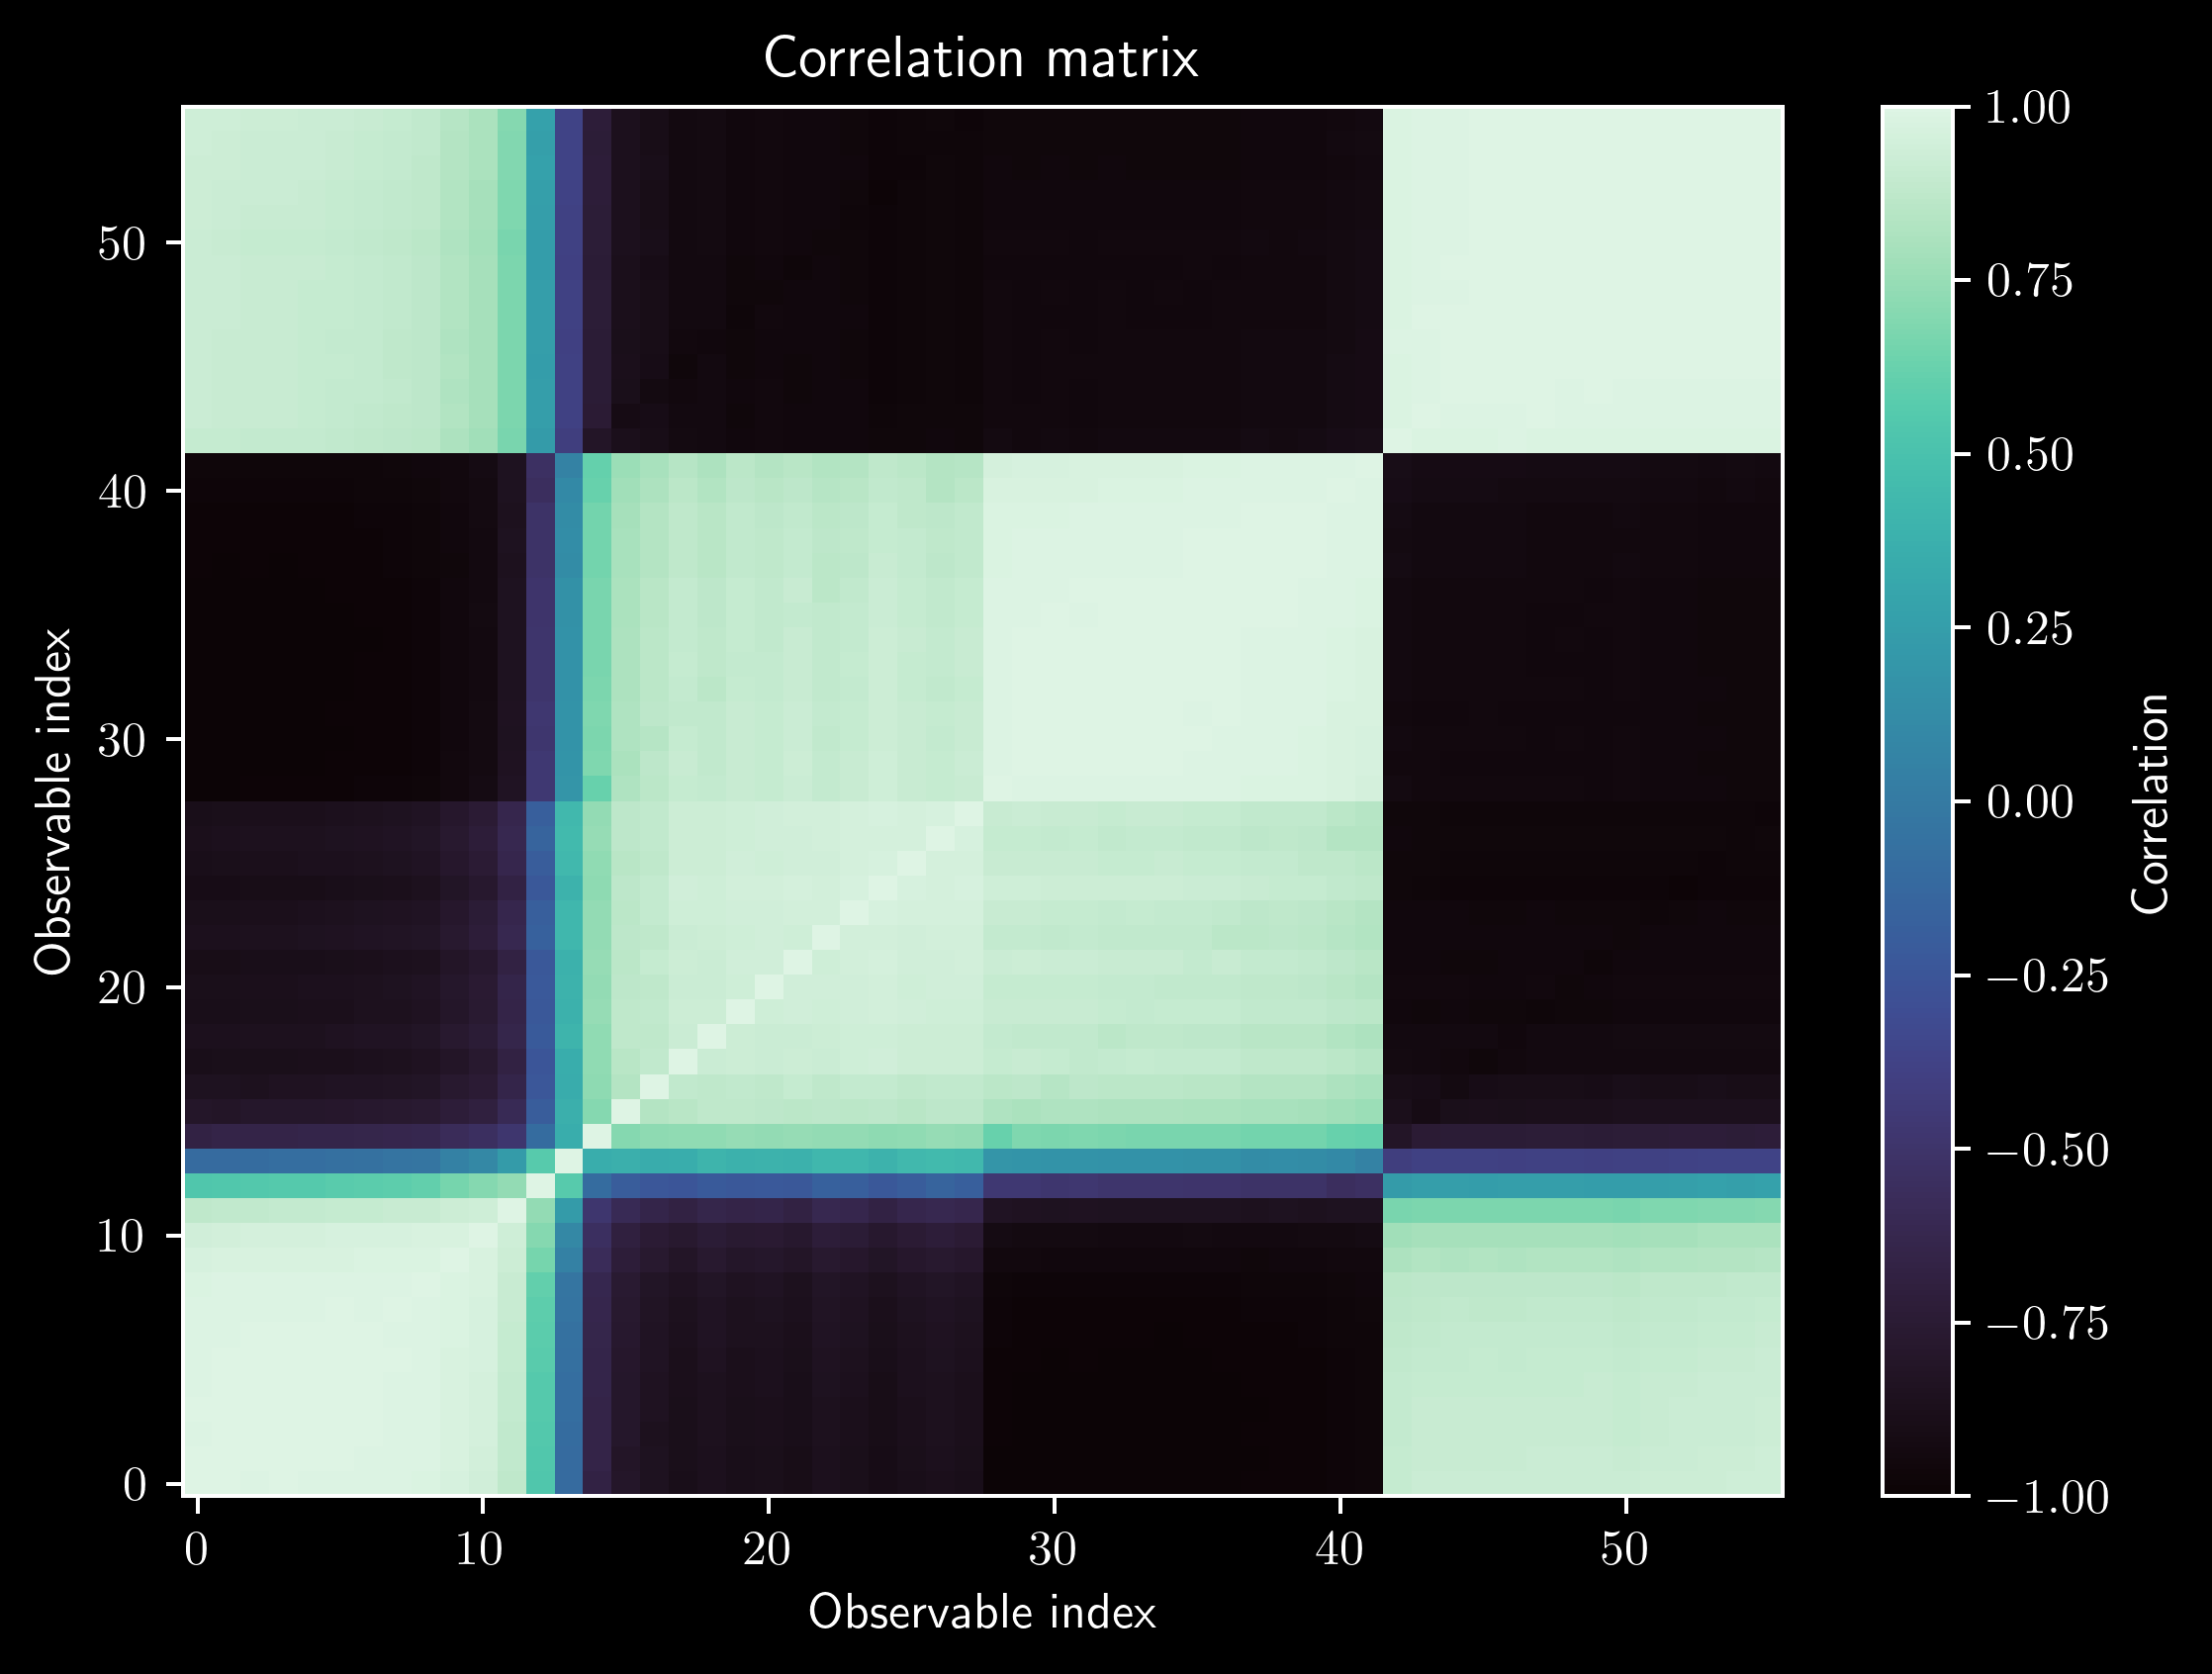

In [181]:
plt.imshow(Corr, vmin=-1, vmax=1, origin='lower', cmap=cmap, aspect='auto')
plt.colorbar(label='Correlation')
plt.xlabel('Observable index')
plt.ylabel('Observable index')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [186]:
N_mocks = O_fid_all.shape[0]
N_obs = O_fid_all.shape[1]

alpha = (N_mocks - N_obs - 2) / (N_mocks - 1)
# Cinv = alpha * np.linalg.inv(C)
Cinv = alpha * np.linalg.inv(C)

In [187]:
F = D @ Cinv @ D.T
F

array([[ 3.59384622e+06, -8.10816620e+04, -6.03415227e+03,
         8.79634900e+03],
       [-8.10816620e+04,  3.17159107e+05,  6.03251563e+03,
        -1.67370458e+03],
       [-6.03415227e+03,  6.03251563e+03,  6.15555695e+03,
        -7.33149343e+01],
       [ 8.79634900e+03, -1.67370458e+03, -7.33149343e+01,
         3.41608359e+03]])

In [188]:
param_names = ['omega_b', 'omega_cdm', 'n_s', 'sigma8']
F_df = pd.DataFrame(F, index=param_names, columns=param_names)
F_df

,omega_b,omega_cdm,n_s,sigma8
omega_b,3.593846e+06,-81081.662016,-6034.152268,8796.348999
omega_cdm,-8.108166e+04,317159.106858,6032.515626,-1673.704584
n_s,-6.034152e+03,6032.515626,6155.556953,-73.314934
sigma8,8.796349e+03,-1673.704584,-73.314934,3416.083591


In [189]:
param_cov = np.linalg.inv(F)
sigma_params = np.sqrt(np.diag(param_cov))

for name, sig in zip(param_names, sigma_params):
    print(f'{name}: sigma = {sig:.5e}')

omega_b: sigma = 5.30792e-04
omega_cdm: sigma = 1.79873e-03
n_s: sigma = 1.28726e-02
sigma8: sigma = 1.71815e-02


In [190]:
evals = np.linalg.eigvalsh(F)
evals

array([3.38720322e+03, 6.03335783e+03, 3.15272673e+05, 3.59588373e+06])